In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import numpy as np
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data/dataset.csv")
df.columns

Index(['id', 'name', 'blurb', 'state', 'launched_at', 'deadline', 'duration',
       'country', 'category.parent_name', 'category.name', 'goal_usd',
       'pledged_usd', 'backers_count', 'launched_at-year', 'launched_at-month',
       'CCI_index'],
      dtype='object')

In [3]:
df["target"] = df["state"].apply(lambda x: 1 if x == "successful" else 0)

## Dummies

In [4]:
df = pd.get_dummies(df, columns=["category.parent_name"], prefix="cat", drop_first=False, dtype=int)
df = pd.get_dummies(df, columns=["country"], prefix="country", drop_first=False, dtype=int)

## Features names

In [7]:
cat_dummies = [col for col in df.columns if col.startswith("cat_")]
country_dummies = [col for col in df.columns if col.startswith("country_")]

features_scale = ["duration", "CCI_index"]
features_no_scale = cat_dummies + country_dummies

## Number of words in blurb

In [10]:
df["blurb_length"] = df["blurb"].apply(lambda x: len(str(x).split()))
features_scale.append("blurb_length")

<Axes: >

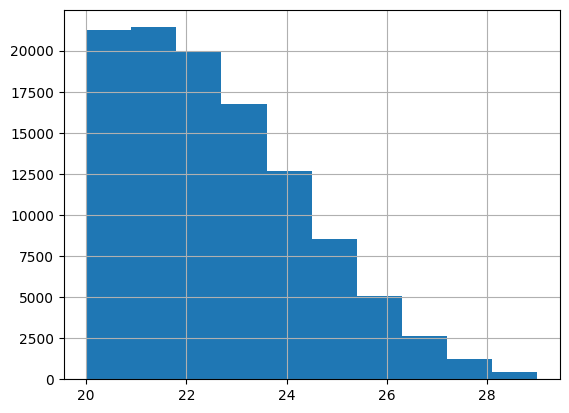

In [11]:
df[df["blurb_length"] < 30]["blurb_length"].hist()

## Sentiment Analysis

$\text{Compound Score} = \frac{x}{\sqrt{x^2 + \alpha}}$, $\alpha = 15$

$x$ is the sum of the scores for all the words in the blurb. A word's score is high when it is assoociated with a positive sentiment and low (negative) when associated with a negative sentiment. This score is adjusted depending on the context in which the word is located.

In [12]:
# score between +0.05 and +1.0: positive sentiment
# score between -0.05 and +0.05: neutral sentiment
# score between -1.0 and -0.05: negative sentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
df["sentiment_score"] = df["blurb"].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
features_scale.append("sentiment_score")

<Axes: >

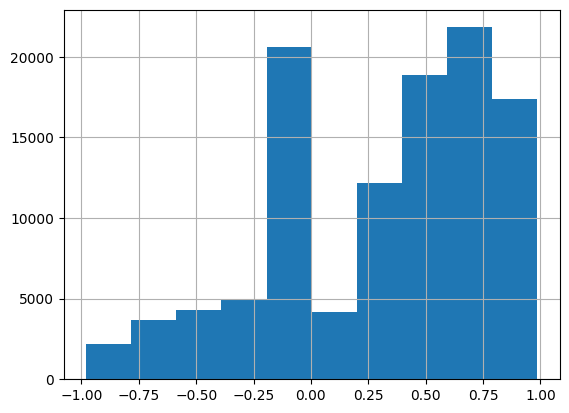

In [13]:
df["sentiment_score"].hist()

## Vocabulary level

$\text{Readability Score} = 206.835 - 1.015 \left( \frac{\text{total words}}{\text{total sentences}} \right) - 84.6 \left( \frac{\text{total syllables}}{\text{total words}} \right)$

In [14]:
# The higher the score is, the easier the blurb is to read

import textstat

df["readability_score"] = df["blurb"].apply(lambda x: textstat.flesch_reading_ease(str(x)))
features_scale.append("readability_score")

<Axes: >

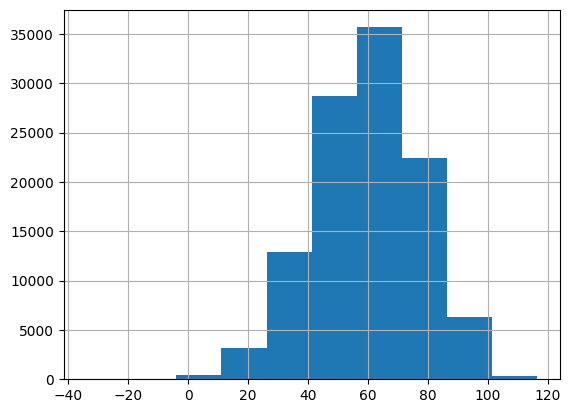

In [15]:
df["readability_score"].hist()

## Name/Blurb similarity

In [16]:
import spacy
nlp = spacy.load("en_core_web_md")
print("Model downloaded !")

Model downloaded !


In [17]:
names = df['name'].astype(str).tolist()
blurbs = df['blurb'].astype(str).tolist()

similarities = []
for doc_name, doc_blurb in zip(nlp.pipe(names), nlp.pipe(blurbs)):
    similarities.append(doc_name.similarity(doc_blurb))

df['name_blurb_similarity'] = similarities
features_scale.append("name_blurb_similarity")

<Axes: >

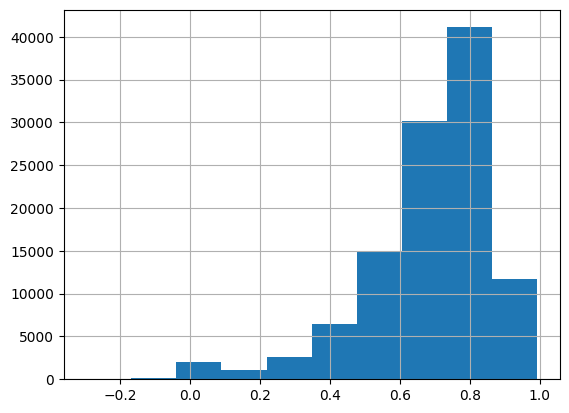

In [18]:
df['name_blurb_similarity'].hist()

## Feature calculations

<Axes: >

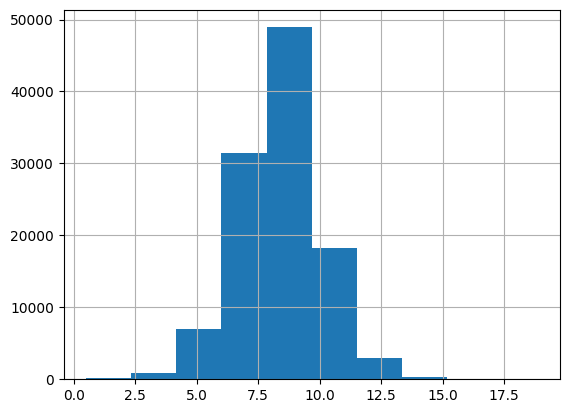

In [21]:
df["log_goal"] = np.log1p(df["goal_usd"])
features_scale.append("log_goal")

df["log_goal"].hist()

<Axes: >

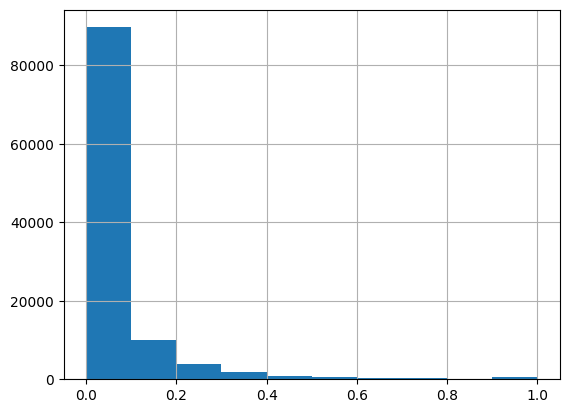

In [22]:
df["CCI_per_goal"] = df["CCI_index"] / df["goal_usd"]
features_scale.append("CCI_per_goal")

df[df["CCI_per_goal"] < 1]["CCI_per_goal"].hist()

In [23]:
import numpy as np

df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_end = int(0.6 * len(df))
val_end = int(0.8 * len(df))

df_train = df_shuffled.iloc[:train_end]
df_val = df_shuffled.iloc[train_end:val_end]
df_test = df_shuffled.iloc[val_end:]

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Train: 66096 | Val: 22032 | Test: 22033


<Axes: >

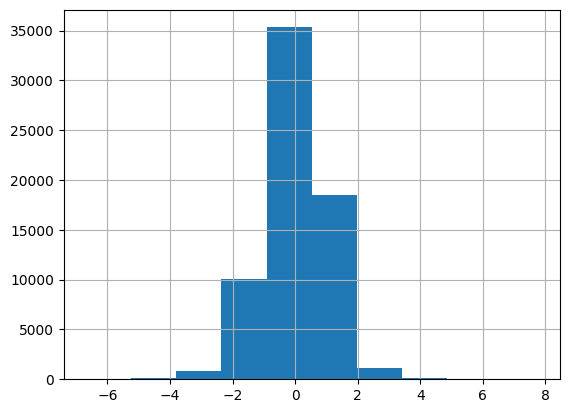

In [24]:
stats = df_train.groupby("category.name")["log_goal"].agg(["mean", "std"]).reset_index()

mean_dict = stats.set_index("category.name")["mean"].to_dict()
std_dict = stats.set_index("category.name")["std"].to_dict()

def apply_zscore(target_df):
    m = target_df["category.name"].map(mean_dict)
    s = target_df["category.name"].map(std_dict).replace(0, 1).fillna(1)
    return (target_df["log_goal"] - m) / s

df_train["z-score_log_goal"] = apply_zscore(df_train)
df_val["z-score_log_goal"] = apply_zscore(df_val)
df_test["z-score_log_goal"] = apply_zscore(df_test)
features_no_scale.append("z-score_log_goal")

df_train["z-score_log_goal"].hist()

In [25]:
features_scale

['duration',
 'CCI_index',
 'blurb_length',
 'sentiment_score',
 'readability_score',
 'name_blurb_similarity',
 'log_goal',
 'CCI_per_goal']

In [26]:
features_no_scale

['cat_Art',
 'cat_Comics',
 'cat_Crafts',
 'cat_Dance',
 'cat_Design',
 'cat_Fashion',
 'cat_Film & Video',
 'cat_Food',
 'cat_Games',
 'cat_Journalism',
 'cat_Music',
 'cat_Photography',
 'cat_Publishing',
 'cat_Technology',
 'cat_Theater',
 'country_AU',
 'country_CA',
 'country_GB',
 'country_NZ',
 'country_US',
 'z-score_log_goal']